# 02 · Feature engineering and leakage checks
The pre-departure models may only use information available when the schedule is published. This notebook documents the feature table (`sql/features` + `flightops.features`) and the checks behind it.

In [1]:
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")
import duckdb, pandas as pd, numpy as np, matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": .3,
                     "axes.spines.top": False, "axes.spines.right": False})
con = duckdb.connect(str(ROOT / "data/warehouse/flightops.duckdb"), read_only=True)
q = lambda s: con.execute(s).df()
from flightops.features import ALL_FEATURES, ROTATION_FEATURES, TE_FEATURES

In [2]:
print(len(ALL_FEATURES), 'pre-departure features'); ALL_FEATURES

22 pre-departure features


['carrier',
 'origin',
 'dest',
 'dep_hour',
 'arr_hour',
 'crs_dep_min_of_day',
 'day_of_week',
 'is_weekend',
 'days_to_holiday',
 'distance_mi',
 'crs_elapsed_min',
 'sched_speed_mpm',
 'origin_sched_deps_day',
 'origin_sched_deps_hour',
 'dest_sched_arrs_hour',
 'carrier_sched_day',
 'te_route_delay',
 'te_route_cancel',
 'te_carrier_origin_delay',
 'te_carrier_origin_cancel',
 'te_flight_delay',
 'te_flight_cancel']

In [3]:
q("SELECT split, min(flight_date) AS first_day, max(flight_date) AS last_day, count(*) n, avg(arr_del15) delay_rate, avg(cancelled) cancel_rate FROM features.flight_features GROUP BY 1 ORDER BY 2")

,split,first_day,last_day,n,delay_rate,cancel_rate
0,train,2025-08-01,2026-03-31,4594643,0.215252,0.019756
1,valid,2026-04-01,2026-05-31,1209653,0.208212,0.009140
2,test,2026-06-01,2026-07-31,1239546,0.270451,0.021418


## Time-based split
Train Aug 2025–Mar 2026, validation Apr–May 2026, test Jun–Jul 2026. The test delay rate (27%) is well above training (21.5%) - a real distribution shift the models must live with.

## Leakage check 1 - aircraft rotation features
BTS reports the tail number of the aircraft that actually operated. Cancelled flights often have no tail at all:

In [4]:
q('SELECT tail_number IS NULL AS missing_tail, count(*) n, avg(cancelled) cancel_rate FROM features.flight_features GROUP BY 1')

,missing_tail,n,cancel_rate
0,False,7026068,0.015742
1,True,17774,1.000000


In [5]:
q('SELECT sched_turn_min IS NULL AS no_turn, tail_leg_of_day = 1 AS first_leg, count(*) n, avg(cancelled) cancel_rate FROM features.flight_features GROUP BY ALL ORDER BY ALL')

,no_turn,first_leg,n,cancel_rate
0,False,False,5132427,0.012395
1,True,False,146423,0.168628
2,True,True,1747218,0.012761
3,True,<NA>,17774,1.000000


A missing tail means 100% cancelled, and 'no turn time but not first leg' has a 17% cancellation rate vs ~1.3% otherwise. These features encode the outcome, so tail_leg_of_day, tail_legs_day, sched_turn_min are **excluded** from the served models (kept only as a labelled day-of-operations comparison).

## Leakage check 2 - day of month
With a time split the test months never appear in training, so day-of-month can only memorise specific disruption days (e.g. the late-January storm). It is excluded; distance to the nearest federal holiday is used instead.

In [6]:
q('SELECT day_of_month, avg(cancelled) cancel_rate FROM features.flight_features WHERE split = \'train\' GROUP BY 1 ORDER BY 2 DESC LIMIT 5')

,day_of_month,cancel_rate
0,25,0.064012
1,26,0.044392
2,24,0.039947
3,23,0.034224
4,31,0.032170


## Target encodings - out-of-fold on train, train-only statistics elsewhere

In [7]:
te = q('''SELECT split, avg(te_route_delay) mean_te, corr(te_route_delay, arr_del15) corr_with_target
           FROM features.flight_features GROUP BY 1 ORDER BY 1''')
te

,split,mean_te,corr_with_target
0,test,0.215197,0.106998
1,train,0.215761,0.140761
2,valid,0.216345,0.111733


The out-of-fold encoding correlates 0.14 with the target on train vs ~0.11 on validation/test. Some gap is expected (in-period vs out-of-period statistics), but there is no leakage-sized jump; a naive in-sample encoding would inflate train far more.

## Schedule congestion features

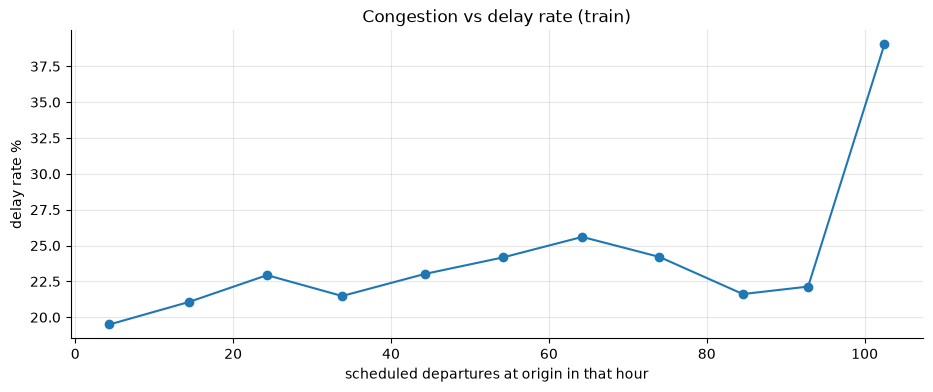

In [8]:
s = q('''SELECT least(floor(origin_sched_deps_hour / 10), 12) AS b, avg(origin_sched_deps_hour) deps_hour,
          avg(arr_del15) delay_rate, count(*) n FROM features.flight_features WHERE split='train' GROUP BY 1 ORDER BY 1''')
plt.plot(s.deps_hour, 100*s.delay_rate, 'o-'); plt.xlabel('scheduled departures at origin in that hour'); plt.ylabel('delay rate %')
plt.title('Congestion vs delay rate (train)'); plt.show()

## Holiday proximity

In [9]:
hd = q('''SELECT days_to_holiday, avg(arr_del15) delay_rate, avg(cancelled) cancel_rate, count(*) n
          FROM features.flight_features GROUP BY 1 ORDER BY 1''')
hd.head(10)

,days_to_holiday,delay_rate,cancel_rate,n
0,0,0.239853,0.020544,204295
1,1,0.234515,0.017538,409747
2,2,0.238598,0.022491,415269
3,3,0.253219,0.016052,440511
4,4,0.223503,0.011366,399519
5,5,0.217933,0.018891,367476
6,6,0.222238,0.038047,380213
7,7,0.221046,0.032377,373788
8,8,0.194212,0.019431,318771
9,9,0.188350,0.009851,266562


## Feature drift train vs test

In [10]:
cols = ['crs_dep_min_of_day','distance_mi','origin_sched_deps_day','carrier_sched_day','te_route_delay','te_flight_delay']
dr = q(f'''SELECT split, {', '.join(f'avg({c}) AS {c}' for c in cols)} FROM features.flight_features GROUP BY 1''').set_index('split').T
dr['test_vs_train_%'] = (100 * (dr.test / dr.train - 1)).round(2); dr

split,train,valid,test,test_vs_train_%
crs_dep_min_of_day,802.791050,807.980771,809.321943,0.81
distance_mi,842.786908,842.493530,854.808409,1.43
origin_sched_deps_day,360.801468,380.418088,384.802696,6.65
carrier_sched_day,2256.271984,2417.523251,2481.529234,9.98
te_route_delay,0.215761,0.216345,0.215197,-0.26
te_flight_delay,0.214169,0.215651,0.214903,0.34


Schedule-shape inputs are stable; schedule volume is 7-10% higher in the summer test window. The larger shift is in the outcome (summer delays), which is why test calibration drifts while ranking quality holds up.